In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau




# Set random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir="

E0000 00:00:1764687396.662377      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764687396.745791      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
DATA_DIR = Path("/kaggle/input/stanford-rna-3d-folding/")  # or wherever you uploaded files

# File paths
TRAIN_SEQ_PATH = DATA_DIR / 'train_sequences.csv'
TRAIN_LABELS_PATH = DATA_DIR / 'train_labels.csv'
VAL_SEQ_PATH = DATA_DIR / 'validation_sequences.csv'
VAL_LABELS_PATH = DATA_DIR / 'validation_labels.csv'
TEST_SEQ_PATH = DATA_DIR / 'test_sequences.csv'

In [3]:
train_sequences = pd.read_csv(TRAIN_SEQ_PATH)
train_labels = pd.read_csv(TRAIN_LABELS_PATH)

val_sequences = pd.read_csv(VAL_SEQ_PATH)
val_labels = pd.read_csv(VAL_LABELS_PATH)

test_sequences = pd.read_csv(TEST_SEQ_PATH)

print(f"Train sequences: {train_sequences.shape}, Train labels: {train_labels.shape}")
print(f"Validation sequences: {val_sequences.shape}, Validation labels: {val_labels.shape}")

Train sequences: (844, 5), Train labels: (137095, 6)
Validation sequences: (12, 5), Validation labels: (2515, 123)


In [4]:
# Nucleotide composition analysis
# RNA nucleotides: A (Adenine), U (Uracil), G (Guanine), C (Cytosine)
def analyze_nucleotide_composition(sequences, dp=True):
    all_nucleotides = ''.join(sequences)
    total = len(all_nucleotides)
    composition = Counter(all_nucleotides)
    if dp:
      print(f"\nTotal nucleotides: {total:,}")
      print("\nNucleotide frequencies:")
      for nt in ['A', 'U', 'G', 'C']:
          count = composition.get(nt, 0)
          pct = (count / total) * 100 if total > 0 else 0
          print(f"  {nt}: {count:,} ({pct:.2f}%)")

    # Check for unexpected characters
    expected_nts = set('AUGC')
    unexpected = set(composition.keys()) - expected_nts
    if unexpected:
        print(f"\n Unexpected characters found: {unexpected}")

    return composition

print("\nTRAINING SET:")
train_comp = analyze_nucleotide_composition(train_sequences['sequence'])

print("\n" + "-" * 80)
print("VALIDATION SET:")
val_comp = analyze_nucleotide_composition(val_sequences['sequence'])


TRAINING SET:

Total nucleotides: 137,095

Nucleotide frequencies:
  A: 32,524 (23.72%)
  U: 29,178 (21.28%)
  G: 41,450 (30.23%)
  C: 33,937 (24.75%)

 Unexpected characters found: {'X', '-'}

--------------------------------------------------------------------------------
VALIDATION SET:

Total nucleotides: 2,515

Nucleotide frequencies:
  A: 509 (20.24%)
  U: 586 (23.30%)
  G: 765 (30.42%)
  C: 655 (26.04%)


In [5]:
VALID_NTS = set(['A','C','G','U'])

def find_bad_nts(seq):
    return set(seq) - VALID_NTS

# Replace clean_sequences_labels with:
def clean_sequences_labels(seq_df, labels_df):
    # create target_id in labels
    labels_df['target_id'] = labels_df['ID'].str.rsplit('_', n=1).str[0]
    # find sequences with unexpected chars
    seq_df['bad_nts'] = seq_df['sequence'].apply(lambda s: set(s) - VALID_NTS)
    bad_mask = seq_df['bad_nts'].apply(len) > 0
    if bad_mask.sum() > 0:
        print(f"Removing {bad_mask.sum()} sequences due to unexpected nucleotides: example: {seq_df.loc[bad_mask,'target_id'].tolist()[:3]}")
    seq_df = seq_df[~bad_mask].copy()
    seq_df.drop(columns=['bad_nts'], inplace=True)

    # filter labels to valid residue names (safe)
    labels_df = labels_df[labels_df['resname'].isin(VALID_NTS)].copy()

    # Optional: ensure we only keep labels that belong to sequences that remain
    labels_df = labels_df[labels_df['target_id'].isin(seq_df['target_id'])].copy()

    return seq_df, labels_df


# Apply cleaning
train_sequences, train_labels = clean_sequences_labels(train_sequences, train_labels)
val_sequences, val_labels = clean_sequences_labels(val_sequences, val_labels)

Removing 4 sequences due to unexpected nucleotides: example: ['6WB1_C', '6Y0C_IN1', '7SLP_R']


In [6]:
print(f"Train sequences: {train_sequences.shape}, Train labels: {train_labels.shape}")
print(f"Validation sequences: {val_sequences.shape}, Validation labels: {val_labels.shape}")

print(train_labels.isna().sum())  
print(val_labels.isna().sum())  

Train sequences: (840, 5), Train labels: (136716, 7)
Validation sequences: (12, 5), Validation labels: (2515, 124)
ID              0
resname         0
resid           0
x_1          5981
y_1          5981
z_1          5981
target_id       0
dtype: int64
ID           0
resname      0
resid        0
x_1          0
y_1          0
            ..
z_39         0
x_40         0
y_40         0
z_40         0
target_id    0
Length: 124, dtype: int64


In [7]:
# Check nucleotide composition after cleaning
train_comp = analyze_nucleotide_composition(train_sequences['sequence'], dp=False)
val_comp = analyze_nucleotide_composition(val_sequences['sequence'], dp=False)

train_sequences['seq_length'] = train_sequences['sequence'].str.len()
val_sequences['seq_length'] = val_sequences['sequence'].str.len()

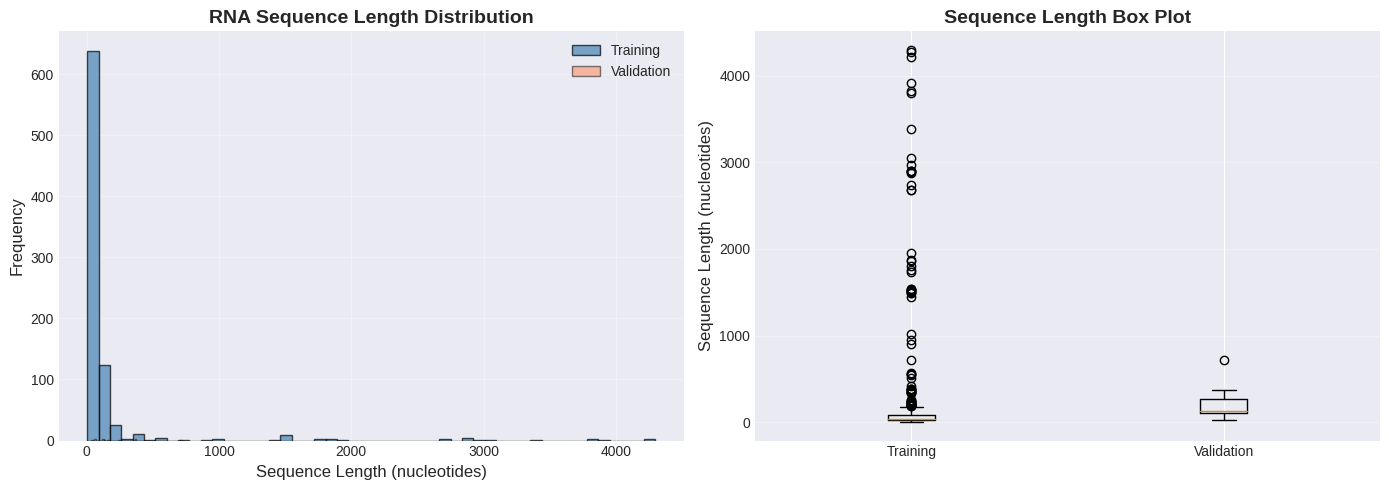


Sequence length range: 3 - 4298 nucleotides


In [8]:
# Visualize sequence length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_sequences['seq_length'], bins=50, color='steelblue',
             edgecolor='black', alpha=0.7, label='Training')
axes[0].hist(val_sequences['seq_length'], bins=50, color='coral',
             edgecolor='black', alpha=0.5, label='Validation')
axes[0].set_xlabel('Sequence Length (nucleotides)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('RNA Sequence Length Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
data_to_plot = [train_sequences['seq_length'], val_sequences['seq_length']]
axes[1].boxplot(data_to_plot, labels=['Training', 'Validation'])
axes[1].set_ylabel('Sequence Length (nucleotides)', fontsize=12)
axes[1].set_title('Sequence Length Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nSequence length range: {train_sequences['seq_length'].min()} - {train_sequences['seq_length'].max()} nucleotides")


Residue types distribution:
resname
G    41356
C    33847
A    32436
U    29077
Name: count, dtype: int64


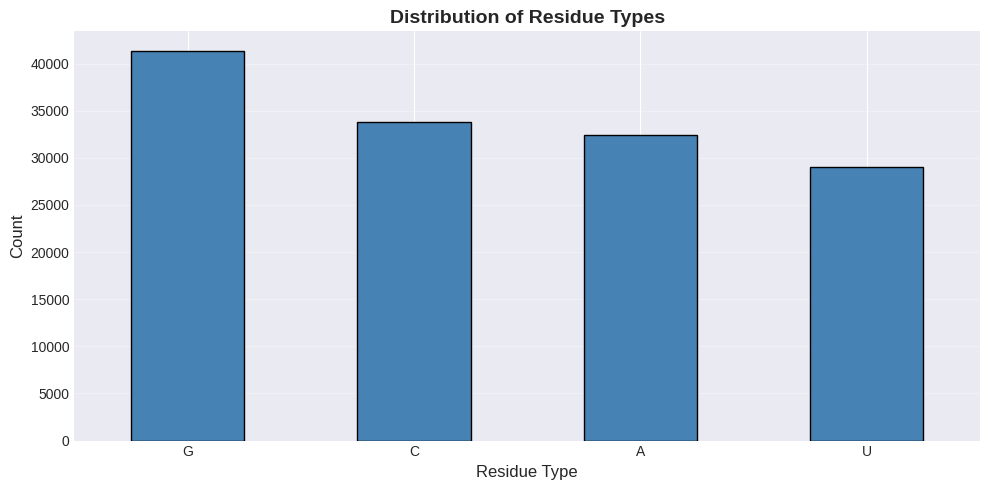


Residue ID statistics:
count   136716.0000
mean       899.5921
std       1014.7526
min          1.0000
25%         62.0000
50%        486.0000
75%       1462.0000
max       4298.0000
Name: resid, dtype: float64


In [9]:
# Analyze residue information

if 'resname' in train_labels.columns:
    print("\nResidue types distribution:")
    residue_counts = train_labels['resname'].value_counts()
    print(residue_counts)

    # Visualize residue distribution
    plt.figure(figsize=(10, 5))
    residue_counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.xlabel('Residue Type', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.title('Distribution of Residue Types', fontsize=14, fontweight='bold')
    plt.xticks(rotation=0)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

if 'resid' in train_labels.columns:
    print("\nResidue ID statistics:")
    print(train_labels['resid'].describe())

Debug: Unique IDs for plotting: ['1SCL_A' '1RNK_A' '1RHT_A']


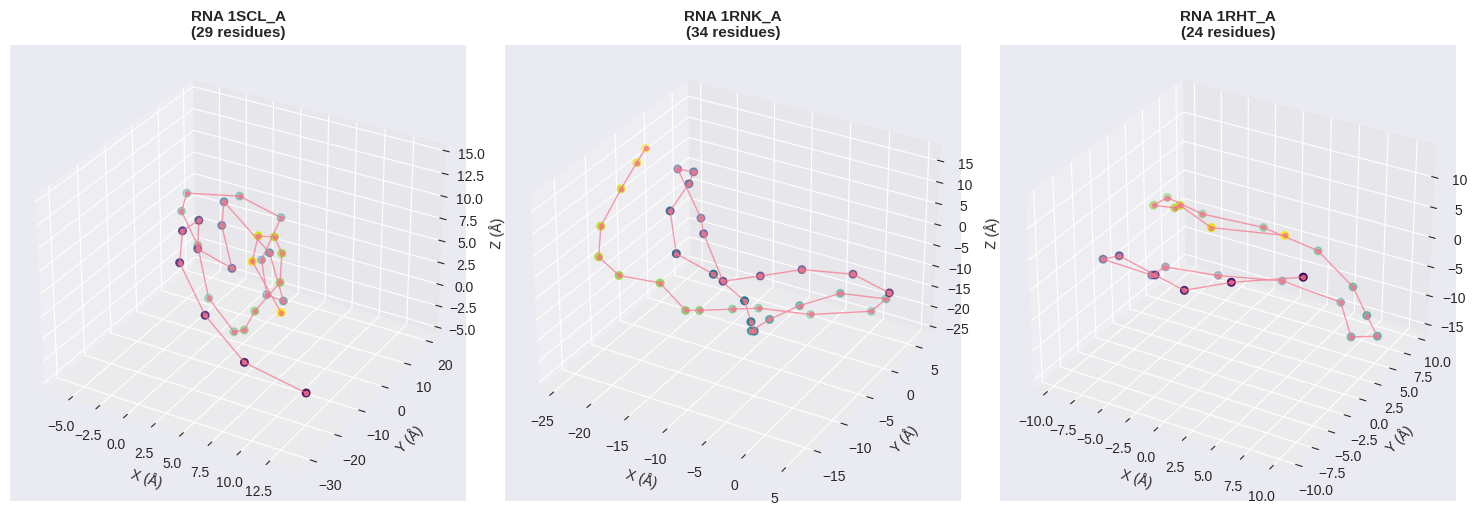


 Displayed 3D structures of first 3 RNA sequences


In [10]:
# get unique ones, and take the first 3.
unique_ids_extracted = train_labels['target_id'].unique()[:3]

print(f"Debug: Unique IDs for plotting: {unique_ids_extracted}")

fig = plt.figure(figsize=(15, 5))

# Define the actual coordinate column names from train_labels
actual_coord_cols = ['x_1', 'y_1', 'z_1']

for idx, seq_id in enumerate(unique_ids_extracted, 1):
    # Get coordinates for this sequence
    # Filter train_labels to get data relevant to the current seq_id
    mask = train_labels['ID'].str.startswith(seq_id + '_')
    seq_data = train_labels[mask]

    # Ensure that seq_data is not empty and has the required coordinate columns
    if len(seq_data) > 0 and all(col in seq_data.columns for col in actual_coord_cols):
        ax = fig.add_subplot(1, 3, idx, projection='3d')

        # Use the correct column names for coordinates
        x = seq_data['x_1'].values
        y = seq_data['y_1'].values
        z = seq_data['z_1'].values

        # Plot backbone
        ax.plot(x, y, z, 'o-', markersize=3, linewidth=1, alpha=0.7)
        ax.scatter(x, y, z, c=range(len(x)), cmap='viridis', s=30)

        ax.set_xlabel('X (Å)', fontsize=10)
        ax.set_ylabel('Y (Å)', fontsize=10)
        ax.set_zlabel('Z (Å)', fontsize=10)
        ax.set_title(f'RNA {seq_id}\n({len(seq_data)} residues)',
                    fontsize=11, fontweight='bold')
    else:
        print(f"  Skipping sequence ID '{seq_id}': No data found or missing coordinate columns ('x_1', 'y_1', 'z_1').")

plt.tight_layout()
plt.show()
print("\n Displayed 3D structures of first 3 RNA sequences")

Debug: Unique IDs for plotting: ['1SCL_A' '1RNK_A' '1RHT_A']


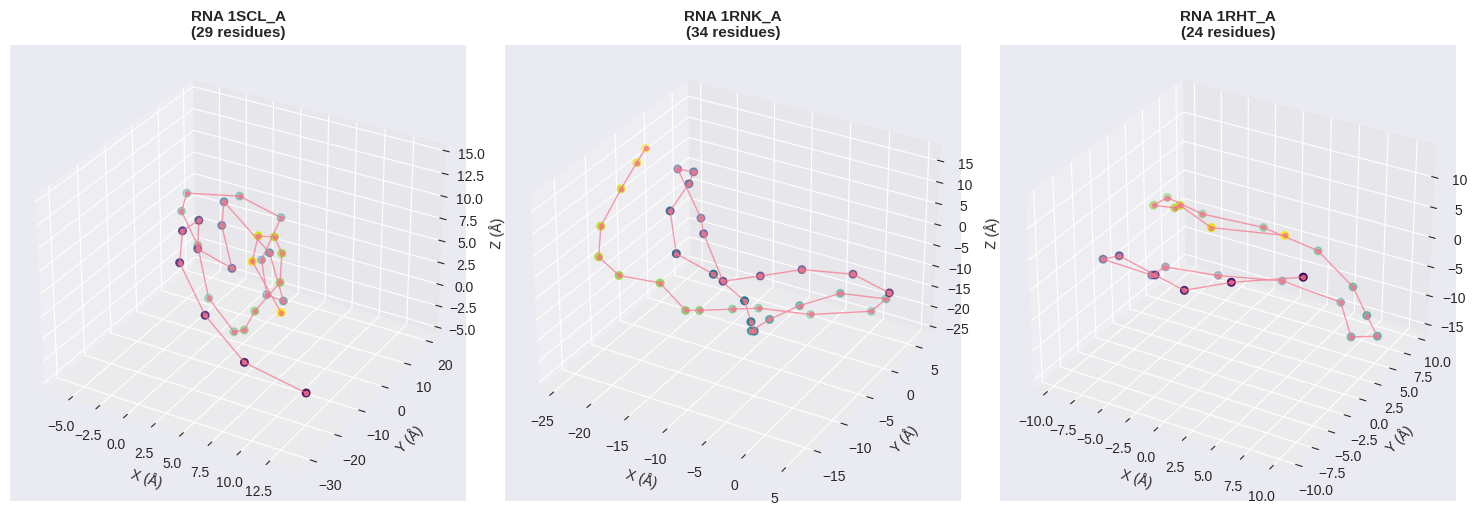


 Displayed 3D structures of first 3 RNA sequences


In [11]:
# get unique ones, and take the first 3.
unique_ids_extracted = train_labels['target_id'].unique()[:3]

print(f"Debug: Unique IDs for plotting: {unique_ids_extracted}")

fig = plt.figure(figsize=(15, 5))

# Define the actual coordinate column names from train_labels
actual_coord_cols = ['x_1', 'y_1', 'z_1']

for idx, seq_id in enumerate(unique_ids_extracted, 1):
    # Get coordinates for this sequence
    # Filter train_labels to get data relevant to the current seq_id
    mask = train_labels['ID'].str.startswith(seq_id + '_')
    seq_data = train_labels[mask]

    # Ensure that seq_data is not empty and has the required coordinate columns
    if len(seq_data) > 0 and all(col in seq_data.columns for col in actual_coord_cols):
        ax = fig.add_subplot(1, 3, idx, projection='3d')

        # Use the correct column names for coordinates
        x = seq_data['x_1'].values
        y = seq_data['y_1'].values
        z = seq_data['z_1'].values

        # Plot backbone
        ax.plot(x, y, z, 'o-', markersize=3, linewidth=1, alpha=0.7)
        ax.scatter(x, y, z, c=range(len(x)), cmap='viridis', s=30)

        ax.set_xlabel('X (Å)', fontsize=10)
        ax.set_ylabel('Y (Å)', fontsize=10)
        ax.set_zlabel('Z (Å)', fontsize=10)
        ax.set_title(f'RNA {seq_id}\n({len(seq_data)} residues)',
                    fontsize=11, fontweight='bold')
    else:
        print(f"  Skipping sequence ID '{seq_id}': No data found or missing coordinate columns ('x_1', 'y_1', 'z_1').")

plt.tight_layout()
plt.show()
print("\n Displayed 3D structures of first 3 RNA sequences")

Debug: Unique IDs for plotting: ['1SCL_A' '1RNK_A' '1RHT_A']


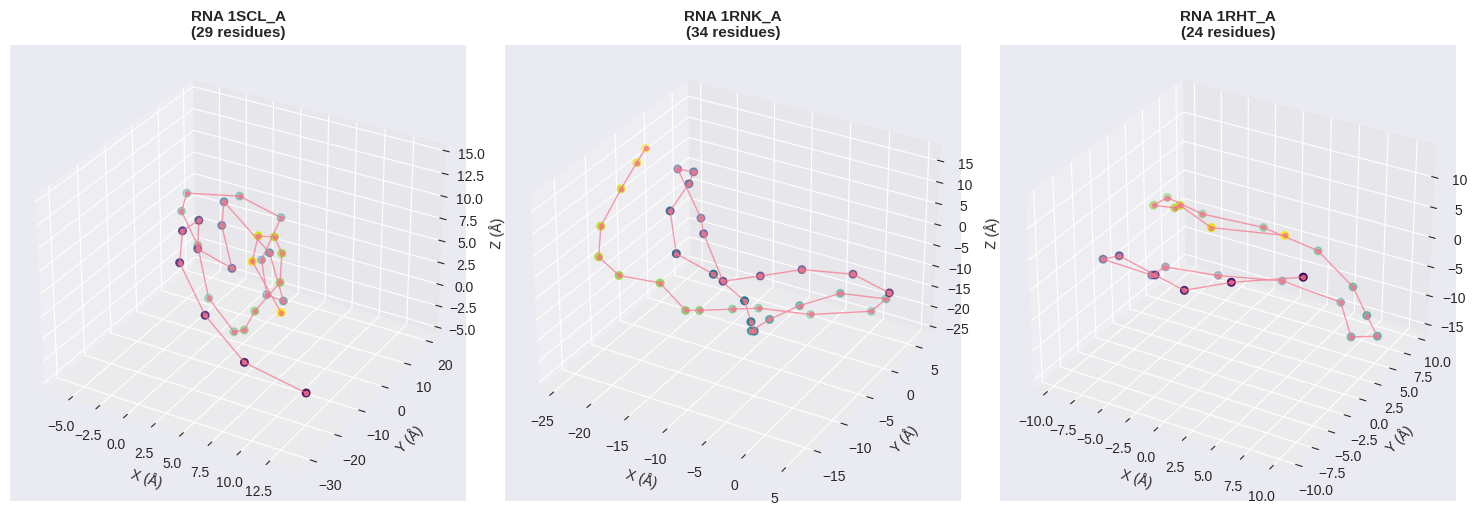


 Displayed 3D structures of first 3 RNA sequences


In [12]:
# get unique ones, and take the first 3.
unique_ids_extracted = train_labels['target_id'].unique()[:3]

print(f"Debug: Unique IDs for plotting: {unique_ids_extracted}")

fig = plt.figure(figsize=(15, 5))

# Define the actual coordinate column names from train_labels
actual_coord_cols = ['x_1', 'y_1', 'z_1']

for idx, seq_id in enumerate(unique_ids_extracted, 1):
    # Get coordinates for this sequence
    # Filter train_labels to get data relevant to the current seq_id
    mask = train_labels['ID'].str.startswith(seq_id + '_')
    seq_data = train_labels[mask]

    # Ensure that seq_data is not empty and has the required coordinate columns
    if len(seq_data) > 0 and all(col in seq_data.columns for col in actual_coord_cols):
        ax = fig.add_subplot(1, 3, idx, projection='3d')

        # Use the correct column names for coordinates
        x = seq_data['x_1'].values
        y = seq_data['y_1'].values
        z = seq_data['z_1'].values

        # Plot backbone
        ax.plot(x, y, z, 'o-', markersize=3, linewidth=1, alpha=0.7)
        ax.scatter(x, y, z, c=range(len(x)), cmap='viridis', s=30)

        ax.set_xlabel('X (Å)', fontsize=10)
        ax.set_ylabel('Y (Å)', fontsize=10)
        ax.set_zlabel('Z (Å)', fontsize=10)
        ax.set_title(f'RNA {seq_id}\n({len(seq_data)} residues)',
                    fontsize=11, fontweight='bold')
    else:
        print(f"  Skipping sequence ID '{seq_id}': No data found or missing coordinate columns ('x_1', 'y_1', 'z_1').")

plt.tight_layout()
plt.show()
print("\n Displayed 3D structures of first 3 RNA sequences")

In [13]:
def handle_missing_coordinates(df, coord_cols=['x_1', 'y_1', 'z_1']):
    # Create mask for coord columns
    mask = df[coord_cols].notna().astype(int)

    # IMPORTANT: include ID/resid/resname so mask_df aligns later
    mask_full = df[['ID', 'resname', 'resid']].copy()
    mask_full[['x_1', 'y_1', 'z_1']] = mask

    # Fill missing coords in actual labels
    df_filled = df.copy()
    df_filled[coord_cols] = df_filled[coord_cols].ffill().bfill()

    return df_filled, mask_full

In [14]:
#Drop NAN
# train_labels = train_labels.dropna(subset=['x_1', 'y_1', 'z_1'])
# val_labels = val_labels.dropna(subset=['x_1', 'y_1', 'z_1'])

# Train labels
train_labels, train_mask = handle_missing_coordinates(train_labels)

# Validation labels
val_labels, val_mask = handle_missing_coordinates(val_labels)

# Check results
print(train_labels.isna().sum())
print(val_labels.isna().sum())

# Inspect mask
display(train_mask.head())
display(val_mask.head())


ID           0
resname      0
resid        0
x_1          0
y_1          0
z_1          0
target_id    0
dtype: int64
ID           0
resname      0
resid        0
x_1          0
y_1          0
            ..
z_39         0
x_40         0
y_40         0
z_40         0
target_id    0
Length: 124, dtype: int64


,ID,resname,resid,x_1,y_1,z_1
0,1SCL_A_1,G,1,1,1,1
1,1SCL_A_2,G,2,1,1,1
2,1SCL_A_3,G,3,1,1,1
3,1SCL_A_4,U,4,1,1,1
4,1SCL_A_5,G,5,1,1,1


,ID,resname,resid,x_1,y_1,z_1
0,R1107_1,G,1,1,1,1
1,R1107_2,G,2,1,1,1
2,R1107_3,G,3,1,1,1
3,R1107_4,G,4,1,1,1
4,R1107_5,G,5,1,1,1


In [15]:
def group_labels(df, id_col='ID', coord_cols=['x_1','y_1','z_1']):
    df['target_id'] = df[id_col].apply(lambda x: "_".join(x.split("_")[:-1]))
    grouped = df.groupby('target_id').apply(
        lambda g: g.sort_values('resid')[coord_cols].values
    ).to_dict()
    return grouped

In [16]:
def group_labels(df, id_col='ID', coord_cols=['x_1','y_1','z_1']):
    df['target_id'] = df[id_col].apply(lambda x: "_".join(x.split("_")[:-1]))
    grouped = df.groupby('target_id').apply(
        lambda g: g.sort_values('resid')[coord_cols].values
    ).to_dict()
    return grouped

In [17]:
def clean_coordinates(coords_array):
    coords_array = np.nan_to_num(coords_array, nan=0.0)
    
    # Optional: clip outliers
    lower, upper = np.percentile(coords_array, [0.1, 99.9])
    coords_array = np.clip(coords_array, lower, upper)
    
    return coords_array

In [18]:
PAD_TOKEN = 4
def pad_or_truncate_sequence(seq, max_len, pad_value=PAD_TOKEN):
    if len(seq) > max_len:
        return seq[:max_len]
    return seq + [pad_value]*(max_len - len(seq))

def pad_or_truncate_coordinates(coords, max_len, pad_value=-1):
    if coords.shape[0] > max_len:
        return coords[:max_len]
    pad_len = max_len - coords.shape[0]
    if pad_len > 0:
        pad_array = np.full((pad_len, 3), pad_value)
        coords = np.vstack([coords, pad_array])
    return coords

In [19]:

def build_attention_mask(seq_lengths, max_len):
    return (np.arange(max_len)[None, :] < np.clip(seq_lengths, 0, max_len)[:, None]).astype(np.int8)

In [21]:
def group_masks(mask_df):
    mask_df['target_id'] = mask_df['ID'].str.rsplit('_', n=1).str[0]
    return mask_df.groupby('target_id').apply(
        lambda g: g.sort_values('resid')[['x_1','y_1','z_1']].values.astype(int)
    ).to_dict()

In [22]:
def normalize_coords(coords, pad_value=-1):
    real = coords[:,0] != pad_value   # selects non-padded rows
    real_coords = coords[real]

    mean = real_coords.mean(axis=0)
    std = real_coords.std(axis=0)

    coords[real] = (real_coords - mean) / (std + 1e-6)
    return coords

In [23]:
def preprocess_dataset(sequences_df, labels_df, mask_df, max_len=None):

    sequences_df = encode_sequences(sequences_df)

    grouped_labels = group_labels(labels_df)
    grouped_mask = group_masks(mask_df)

    # Ensure target_id exists
    assert 'target_id' in sequences_df.columns

    # Drop mismatched lengths
    sequences_df = drop_misaligned_targets(sequences_df, grouped_labels)
    sequences_df = sequences_df[sequences_df['target_id'].isin(grouped_labels)].reset_index(drop=True)

    # Determine max_len only once
    if max_len is None:
        max_len = sequences_df['encoded'].apply(len).max()

    X, Y, M = [], [], []

    for _, row in sequences_df.iterrows():
        tid = row['target_id']

        # Sequence
        enc = pad_or_truncate_sequence(row['encoded'], max_len)

        # Coordinates
        coords = grouped_labels[tid]
        coords = clean_coordinates(coords)
        coords = normalize_coords(coords)
        coords = pad_or_truncate_coordinates(coords, max_len)

        # Mask
        mask = grouped_mask[tid]
        mask = pad_or_truncate_coordinates(mask, max_len, pad_value=0)
        mask = np.clip(mask, 0, 1).astype(int)

        X.append(enc)
        Y.append(coords)
        M.append(mask)

    X = np.array(X)
    Y = np.array(Y)
    M = np.array(M)

    # Attention mask
    seq_lengths = sequences_df['encoded'].apply(len).values
    attention_mask = build_attention_mask(seq_lengths, max_len)

    target_ids = sequences_df['target_id'].tolist()

    return X, Y, M, attention_mask, target_ids, max_len

In [24]:

train_X, train_Y, train_missing_mask, train_attention_mask, train_target_ids, max_len = \
    preprocess_dataset(train_sequences, train_labels, train_mask)
val_X, val_Y, val_missing_mask, val_attention_mask, val_target_ids, _ = \
    preprocess_dataset(val_sequences, val_labels, val_mask, max_len=max_len)


print(f"Train X: {train_X.shape}, Train Y: {train_Y.shape}, Attention Mask: {train_attention_mask.shape}")
print(f"Validation X: {val_X.shape}, Validation Y: {val_Y.shape}, Attention Mask: {val_attention_mask.shape}")

NameError: name 'encode_sequences' is not defined